# Import the Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load Dataset

In [3]:
df = pd.read_csv((r"C:\Users\umani\Downloads\4) house Prediction Data Set (2).csv")
    ,
    sep=r"\s+",
    header=None,
    engine="python"
)

print(df.shape)
df.head()

(506, 14)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


# Assigning Column Names

In [5]:
# Assign Column Names
df.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
              'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO',
              'B', 'LSTAT', 'MEDV']

# Create a pseudo time index

In [6]:
# Create a pseudo time index
df['Time'] = range(len(df))
df.set_index('Time', inplace=True)

# Select MEDV as the time series

In [7]:
# Select MEDV as the time series
ts = df['MEDV']

# Plot Time Series Data

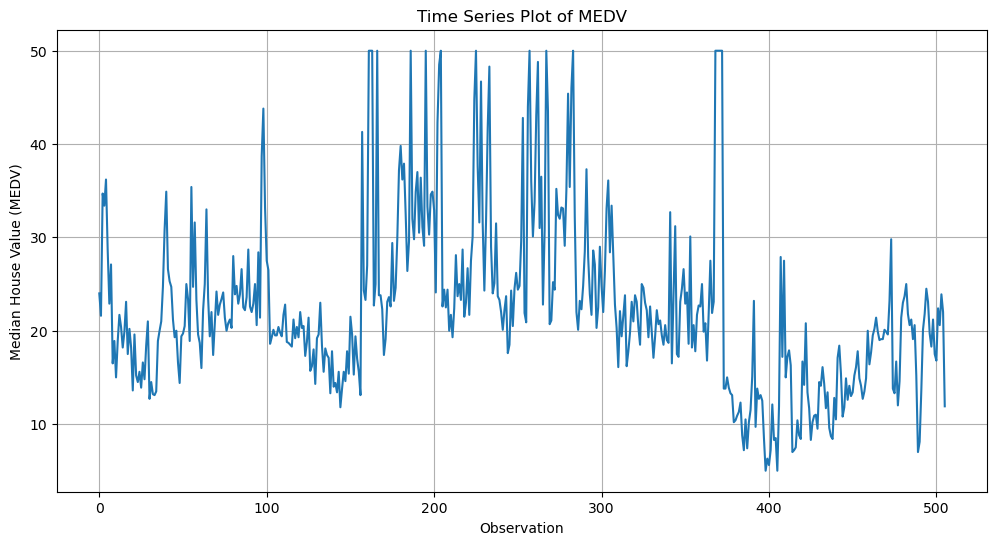

In [8]:
plt.figure(figsize=(12,6))
plt.plot(ts)
plt.title('Time Series Plot of MEDV')
plt.xlabel('Observation')
plt.ylabel('Median House Value (MEDV)')
plt.grid(True)
plt.show()

# Decompose into Trend, Seasonality, and Residuals

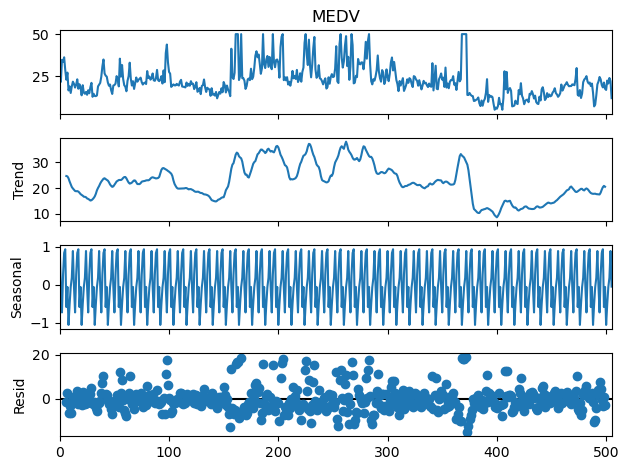

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposition
decomposition = seasonal_decompose(
    ts,
    model='additive',
    period=12
)

# Plot Components
decomposition.plot()
plt.show()

# Moving Average Smoothing

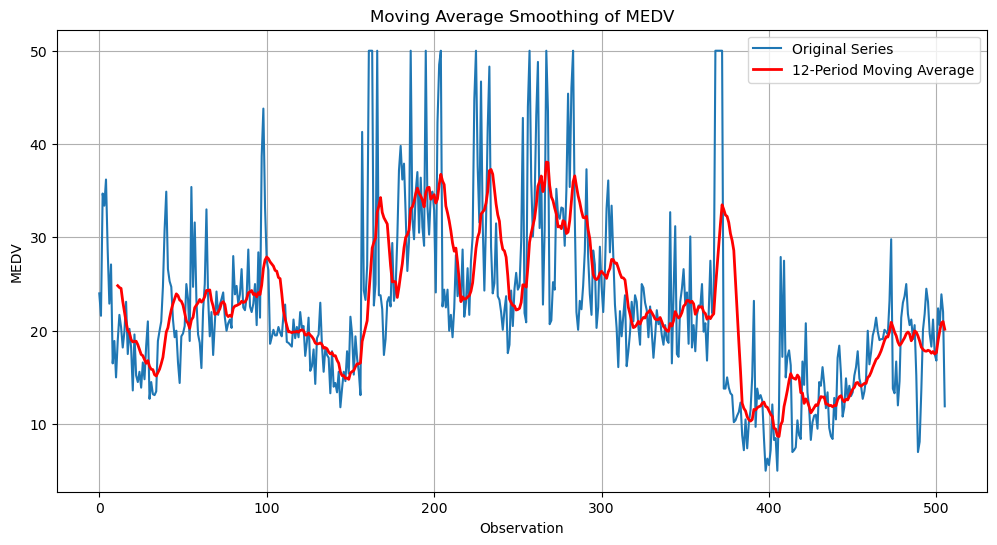

In [10]:
# Calculate Moving Average
moving_avg = ts.rolling(window=12).mean()

# Plot Original vs Smoothed Series
plt.figure(figsize=(12,6))

plt.plot(ts, label='Original Series')
plt.plot(moving_avg,
         color='red',
         linewidth=2,
         label='12-Period Moving Average')

plt.title('Moving Average Smoothing of MEDV')
plt.xlabel('Observation')
plt.ylabel('MEDV')
plt.legend()
plt.grid(True)
plt.show()

# Report Interpretation


In [ ]:
# Report Interpretation

# Time Series Plot

MEDV values fluctuate across observations.
Some upward and downward movements indicate possible trends.

# Decomposition

Trend component shows the long-term movement in house values.
Seasonal component captures recurring patterns.
Residual component contains random fluctuations not explained by trend or seasonality.

# Moving Average

The 12-period moving average smooths short-term fluctuations.
It helps reveal the underlying trend more clearly.
Libraries Used
Pandas
Matplotlib
Statsmodels